In [ ]:
#%pip install torch --no-cache-dir

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.1/532.1 MB 3.6 MB/s eta 0:00:0000:0100:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 KB 3.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 3.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 3.6 MB/s eta 0:00:0000:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 KB 3.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 3.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.6 MB/s eta 0:00:0000:0100:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 3.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 3.7 MB/s eta 0:00:0000:0100:03
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 3.6 MB/s eta 0:00:0000:0100:02
     ━━━━━━━━━━━━━━━━━━━

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import entropy
from sklearn.preprocessing import MinMaxScaler

# Configurações de exibição e plotagem gráfica
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.size'] = 11

# --- CONFIGURAÇÕES DO ALGORITMO 1 DO ARTIGO ---
W_SIZE = 44    # Tamanho da janela estrito
W_SLIDE = 1   # Janela deslizante pura (passo = 1)

# CAMINHO ABSOLUTO CORRIGIDO (Onde os seus arquivos reais estão no Linux)
DATA_DIR = "/home/giovanna/Documents/deteccaoIntrusao/automotive-ids-evaluation-framework-deteccao_intrusao/data/can_train_test/set_01"

print(f"✅ Ambiente configurado com sucesso!")
print(f"Buscando dados no caminho real: '{DATA_DIR}'")

✅ Ambiente configurado com sucesso!
Buscando dados no caminho real: '/home/giovanna/Documents/deteccaoIntrusao/automotive-ids-evaluation-framework-deteccao_intrusao/data/can_train_test/set_01'


Varredura do Diretório e Mapeamento dos Ataques (Set 1)

In [2]:
search_pattern = os.path.join(DATA_DIR, "**/*.csv")
csv_files = glob.glob(search_pattern, recursive=True)

if len(csv_files) == 0:
    print(f"⚠️ Nenhum arquivo .csv encontrado. Verifique se o caminho em DATA_DIR está correto:")
    print(f"Caminho atual: {DATA_DIR}")
else:
    print(f"🔍 Sucesso! Encontrados {len(csv_files)} arquivos .csv nas subpastas.")
    summary_data = []
    
    for file in csv_files:
        filename = os.path.basename(file)
        subfolder = os.path.basename(os.path.dirname(file))
        
        # 1. Abre apenas a primeira linha para descobrir os nomes reais das colunas
        df_sample = pd.read_csv(file, nrows=1)
        columns_list = df_sample.columns.tolist()
        
        # 2. Procura heuristicamente o nome correto da coluna de alvos/labels
        label_col = None
        possible_names = ['Label', 'label', 'Class', 'class', 'Type', 'type', 'Label ']
        for name in possible_names:
            if name in columns_list:
                label_col = name
                break
                
        # Se não achar pelos nomes comuns, pega a última coluna (padrão de datasets CAN)
        if label_col is None:
            label_col = columns_list[-1]
            
        # 3. Leitura rápida usando a coluna detectada
        df_meta = pd.read_csv(file, usecols=[label_col])
        total_packets = len(df_meta)
        
        # Converte para numérico caso esteja mapeado como string (ex: 'Normal', 'Attack')
        # e calcula a soma de ataques
        if df_meta[label_col].dtype == object:
            # Se for string, assume 1 para qualquer coisa que não seja 'normal' ou '0'
            attack_packets = df_meta[label_col].apply(lambda x: 0 if str(x).lower() in ['normal', '0', '0.0'] else 1).sum()
        else:
            attack_packets = int(df_meta[label_col].sum())
            
        normal_packets = total_packets - attack_packets
        attack_ratio = (attack_packets / total_packets) * 100 if total_packets > 0 else 0
        
        if "train" in subfolder.lower() or "train" in filename.lower():
            context = "Treino (DoS/Fuzzing)"
        else:
            context = "Teste (Spoofing/Inéditos)"
        
        summary_data.append({
            "Subpasta": subfolder,
            "Arquivo": filename,
            "Coluna Rótulo": label_col,
            "Total Mensagens": total_packets,
            "Mensagens Normais": normal_packets,
            "Mensagens Ataque": attack_packets,
            "Proporção Ataque (%)": f"{attack_ratio:.2f}%"
        })
    
    df_summary = pd.DataFrame(summary_data)
    print("\n📊 TABELA RESUMO DO DATASET DETECTADO:")
    display(df_summary)

🔍 Sucesso! Encontrados 52 arquivos .csv nas subpastas.

📊 TABELA RESUMO DO DATASET DETECTADO:


,Subpasta,Arquivo,Coluna Rótulo,Total Mensagens,Mensagens Normais,Mensagens Ataque,Proporção Ataque (%)
0,test_04_unknown_vehicle_unknown_attack,triple-3.csv,attack,1993660,1993054,606,0.03%
1,test_04_unknown_vehicle_unknown_attack,fuzzing-3.csv,attack,495332,489220,6112,1.23%
2,test_04_unknown_vehicle_unknown_attack,double-4.csv,attack,1300435,1299820,615,0.05%
3,test_04_unknown_vehicle_unknown_attack,speed-4.csv,attack,1898360,1898296,64,0.00%
4,test_04_unknown_vehicle_unknown_attack,fuzzing-4.csv,attack,619269,619066,203,0.03%
5,test_04_unknown_vehicle_unknown_attack,systematic-4.csv,attack,330614,329692,922,0.28%
6,test_04_unknown_vehicle_unknown_attack,speed-3.csv,attack,2625443,2622302,3141,0.12%
7,test_04_unknown_vehicle_unknown_attack,interval-4.csv,attack,857658,857632,26,0.00%
8,test_04_unknown_vehicle_unknown_attack,interval-3.csv,attack,891053,890946,107,0.01%
9,test_04_unknown_vehicle_unknown_attack,systematic-3.csv,attack,507374,507315,59,0.01%


Análise Exploratória (EDA) do Arquivo de Treino

🔍 Buscando a região de injeção de ataques no arquivo de treino...
🎯 Região encontrada! Plotando das linhas 700391 até 715391.


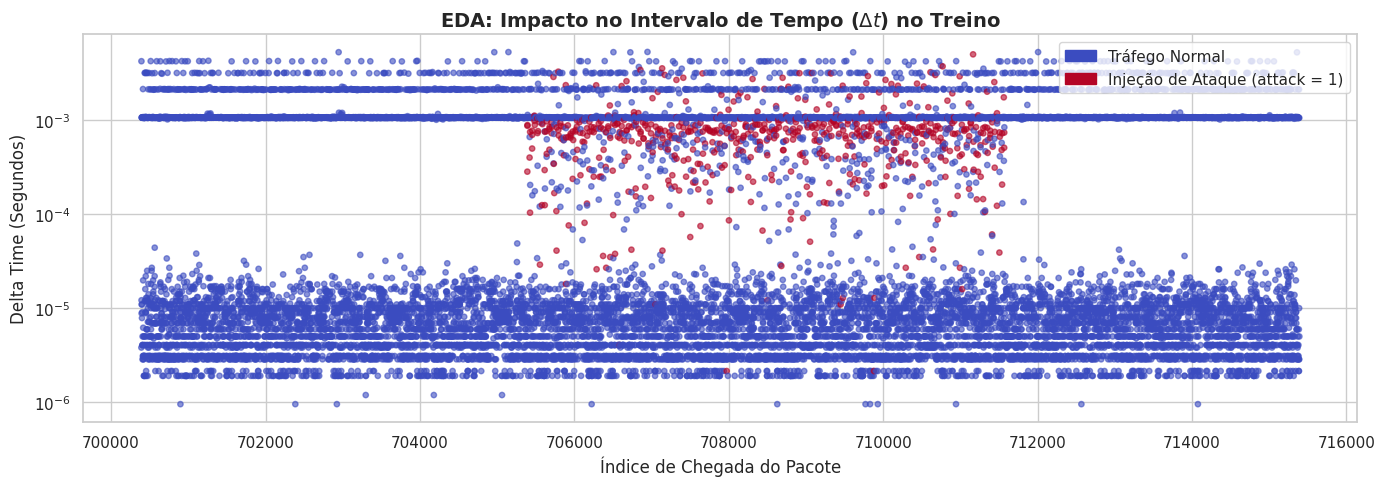

In [3]:
train_file = [f for f in csv_files if "train" in f.lower()]

if len(train_file) > 0:
    # Carrega um pedaço maior para varrer o arquivo atrás de ataques
    print("🔍 Buscando a região de injeção de ataques no arquivo de treino...")
    df_chunk = pd.read_csv(train_file[0], usecols=['timestamp', 'attack'])
    
    # Encontra o primeiro índice onde o ataque acontece (attack == 1)
    attack_indices = df_chunk[df_chunk['attack'] == 1].index
    
    if len(attack_indices) > 0:
        start_idx = max(0, attack_indices[0] - 5000) # Pega 5000 linhas antes do ataque
        end_idx = min(len(df_chunk), start_idx + 15000) # Pega 15000 linhas no total
        df_eda = df_chunk.iloc[start_idx:end_idx].copy()
        print(f"🎯 Região encontrada! Plotando das linhas {start_idx} até {end_idx}.")
    else:
        # Se este arquivo específico for o limpo, pega as primeiras linhas mesmo
        df_eda = df_chunk.head(15000).copy()
        print("ℹ️ Este arquivo de treino específico é 100% limpo. Plotando início.")
        
    # Calcula o intervalo temporal
    df_eda['Delta_t'] = df_eda['timestamp'].diff().fillna(0)
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.scatter(df_eda.index, df_eda['Delta_t'], c=df_eda['attack'], 
               cmap='coolwarm', alpha=0.6, s=15)
    
    ax.set_title("EDA: Impacto no Intervalo de Tempo ($\Delta t$) no Treino", fontsize=14, fontweight='bold')
    ax.set_xlabel("Índice de Chegada do Pacote", fontsize=12)
    ax.set_ylabel("Delta Time (Segundos)", fontsize=12)
    ax.set_yscale('log')
    
    import matplotlib.patches as mpatches
    normal_patch = mpatches.Patch(color='#3b4cc0', label='Tráfego Normal')
    attack_patch = mpatches.Patch(color='#b40426', label='Injeção de Ataque (attack = 1)')
    ax.legend(handles=[normal_patch, attack_patch], loc='upper right')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Arquivo de treino não identificado.")

Análise Exploratória de Dados (EDA) - Janelas de Entropia e Cripto-Análise de Payload

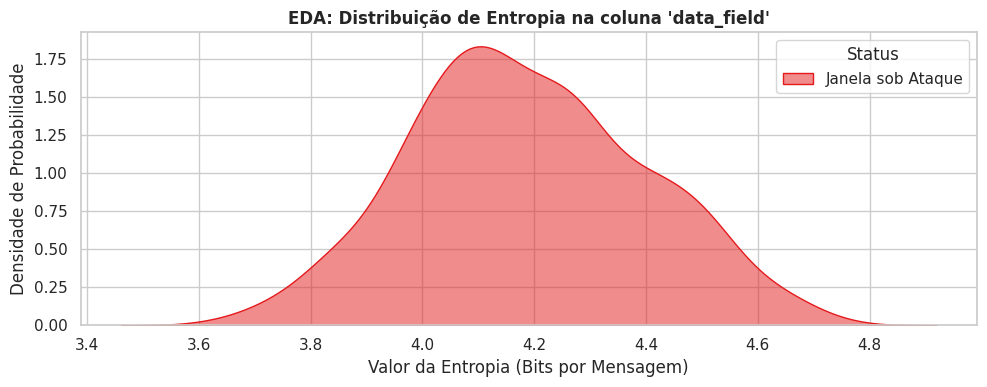

In [4]:
def get_bytes_matrix_fixed(series):
    def parse(x):
        if pd.isna(x): 
            return [0] * 8
        
        # Remove caracteres comuns de formatação (colchetes, espaços, prefixos)
        clean_str = str(x).replace('[', '').replace(']', '').replace('-', '').replace('0x', '').strip()
        
        # Se os bytes estiverem separados por espaço, divide por espaço
        if ' ' in clean_str:
            b = clean_str.split()
        else:
            # Se estiverem grudados (ex: '1A2B3C'), quebra de 2 em 2 caracteres
            b = [clean_str[i:i+2] for i in range(0, len(clean_str), 2)]
            
        # Garante que temos exatamente 8 bytes preenchendo com zeros se faltar
        b += ['00'] * (8 - len(b))
        b = b[:8]
        
        # Converte cada par hexadecimal para inteiro (0 a 255) de forma segura
        return [int(byte, 16) if byte else 0 for byte in b]

    return np.array(series.apply(parse).tolist(), dtype=np.uint8)

# Execução da plotagem de entropia
if len(train_file) > 0:
    df_entropy = pd.read_csv(train_file[0], nrows=30000, usecols=['data_field', 'attack'])
    bytes_mat = get_bytes_matrix_fixed(df_entropy['data_field'])
    
    entropies = []
    chunk_size = 44 
    for i in range(0, len(bytes_mat) - chunk_size, chunk_size):
        chunk = bytes_mat[i:i+chunk_size]
        _, counts = np.unique(chunk, return_counts=True)
        entropies.append((i, entropy(counts, base=2), 1 if df_entropy['attack'].iloc[i:i+chunk_size].sum() > 0 else 0))
        
    df_ent_plot = pd.DataFrame(entropies, columns=['Index', 'Entropia', 'Contém Ataque'])
    
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=df_ent_plot, x="Entropia", hue="Contém Ataque", fill=True, common_norm=False, palette="Set1", alpha=0.5)
    plt.title("EDA: Distribuição de Entropia na coluna 'data_field'", fontweight='bold')
    plt.xlabel("Valor da Entropia (Bits por Mensagem)")
    plt.ylabel("Densidade de Probabilidade")
    plt.legend(title="Status", labels=["Janela sob Ataque", "Janela Normal"])
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Arquivo de treino não identificado para plotagem de entropia.")

em relação as amostras totais qual a quantidade de cada ataque 
e quais sao os ataques?
distruibuicao 
